In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_new = pd.read_excel('C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/HomeSafety_2/RawData/Household_data/RESIDENTIAL_OXON_anon.xlsx')

In [3]:
df_new.columns

Index(['s', 'ABP_Classification_Code', 'ABP_Classification_Desc',
       'Communal Household Flag', '(H) Age - Fine',
       '(H) Household Composition', '(H) Presence of Elderly Parent',
       '(H) Number of Adults in Household', '(H) Family Lifestage v3',
       '(H) Length of Residency', '(H) Property Type 2011', '(H) Tenure 2011',
       '(H) Mosaic UK 7 Type', '(H) Mosaic UK 7 Type Label',
       '(H) Affluence v2', '(H) Water Poverty Flag',
       '(H) Fuel Poverty v2 Flag', '(H) Number of Children v3',
       '(H) Household Income v3 - Bands', 'Station_Ground_Code', 'LSOA11CD',
       'irs.Incident?'],
      dtype='str')

In [4]:
df = df_new.copy() 

In [5]:
df = df_new.copy()

#df = df[df['Station_Ground_Code']=='JX06']
df.rename(columns = {'s':'UPRN'    ,'irs.Incident?':'INCIDENT'}, inplace = True)

df['INCIDENT'] = df['INCIDENT'].replace({'Y': '1', 'N': '0', '': pd.NA}).astype(pd.Int8Dtype())
df.shape

(12315, 22)

SPLIT THE DATA: Next, you define the target and features. This means separating the dataset into the input variables (X) and the target variable (y), which in your case is the Incident column.

In [6]:
cols = []
for c in df.columns:
    cols.append(c)
cols

# target data
y = df[cols[-1]]
y.value_counts()

INCIDENT
0    12239
1       76
Name: count, dtype: Int64

In [7]:
X_cols = cols[0:len(cols)-1]
X = df[df.columns.intersection(X_cols)]
X.head(4)

,UPRN,ABP_Classification_Code,ABP_Classification_Desc,Communal Household Flag,(H) Age - Fine,(H) Household Composition,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,...,(H) Tenure 2011,(H) Mosaic UK 7 Type,(H) Mosaic UK 7 Type Label,(H) Affluence v2,(H) Water Poverty Flag,(H) Fuel Poverty v2 Flag,(H) Number of Children v3,(H) Household Income v3 - Bands,Station_Ground_Code,LSOA11CD
52,100120793465,RD04,Terraced,N,10,4.0,0,1,11.0,11,...,0,22,F22 Boomerang Boarders,13,0,N,0,2,JX06,E01028512
84,100121291410,RD04,Terraced,N,4,5.0,0,1,7.0,3,...,0,11,C11 Rural Vogue,17,0,N,1,5,JX06,E01028502
86,10011873896,RD04,Terraced,N,4,0.0,0,2,6.0,8,...,0,11,C11 Rural Vogue,13,0,N,3,7,JX06,E01028502
138,100120801762,RD04,Terraced,N,4,3.0,0,2,6.0,6,...,0,11,C11 Rural Vogue,14,0,N,2,6,JX06,E01028497


After defining the X, y features: ...perform a train/test split. The reason we do this relatively early is so that part of the data remains completely unseen during training. This allows us to properly evaluate whether the model generalises well.¶

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, stratify = y, random_state = 42)

Training set datatype == Int¶

In [9]:
X_train_int = X_train.dtypes[X_train.dtypes == 'int64']
X_train_int = X_train.select_dtypes('int64')
X_train_obj = X_train.select_dtypes('str')

print(f'The are {X_train_int.shape[1]} float64 formats present >>>\n {X_train_int.columns}') 
print('\n')
print(f'The are {X_train_obj.shape[1]} object/string formats present >>>\n {X_train_obj.columns}') 



The are 12 float64 formats present >>>
 Index(['UPRN', '(H) Age - Fine', '(H) Presence of Elderly Parent',
       '(H) Number of Adults in Household', '(H) Length of Residency',
       '(H) Property Type 2011', '(H) Tenure 2011', '(H) Mosaic UK 7 Type',
       '(H) Affluence v2', '(H) Water Poverty Flag',
       '(H) Number of Children v3', '(H) Household Income v3 - Bands'],
      dtype='str')


The are 7 object/string formats present >>>
 Index(['ABP_Classification_Code', 'ABP_Classification_Desc',
       'Communal Household Flag', '(H) Mosaic UK 7 Type Label',
       '(H) Fuel Poverty v2 Flag', 'Station_Ground_Code', 'LSOA11CD'],
      dtype='str')


In [10]:
X_train_obj_features = X_train_obj.columns
X_train_int_features = X_train_int.columns
X_train_obj_features, X_train_int_features

(Index(['ABP_Classification_Code', 'ABP_Classification_Desc',
        'Communal Household Flag', '(H) Mosaic UK 7 Type Label',
        '(H) Fuel Poverty v2 Flag', 'Station_Ground_Code', 'LSOA11CD'],
       dtype='str'),
 Index(['UPRN', '(H) Age - Fine', '(H) Presence of Elderly Parent',
        '(H) Number of Adults in Household', '(H) Length of Residency',
        '(H) Property Type 2011', '(H) Tenure 2011', '(H) Mosaic UK 7 Type',
        '(H) Affluence v2', '(H) Water Poverty Flag',
        '(H) Number of Children v3', '(H) Household Income v3 - Bands'],
       dtype='str'))

In [11]:
X_train_int_features = X_train_int.columns

X_train_obj = X_train.select_dtypes('str')
X_train_obj_features = X_train_obj.columns
#X_train_obj_features

# Pipeline: Random_Forest

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# 1. Define which columns get which treatment

num_cols = X_train_int_features
#num_cols = ['(H) Age - Fine', '(H) Number of Adults in Household', '(H) Length of Residency', '(H) Affluence v2']
cat_cols = X_train_obj_features
#cat_cols = ['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name', 'LSOA11CD']
cat_cols

Index(['ABP_Classification_Code', 'ABP_Classification_Desc',
       'Communal Household Flag', '(H) Mosaic UK 7 Type Label',
       '(H) Fuel Poverty v2 Flag', 'Station_Ground_Code', 'LSOA11CD'],
      dtype='str')

In [13]:
# 2. Create the transformers
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(
    transformers=[
        ## additional impute in case of missing values in future datasets
        #('impute', SimpleImputer(strategy = "median"), num_cols),
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='drop') # This automatically drops LSOA11CD and anything not listed above
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [14]:
# 3. Bundle it all with your model
from sklearn.ensemble import RandomForestClassifier

pipeline_Random_Forest = Pipeline(
    steps=
                                  [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced')) 
                                  ]
)

# Note: class_weight='balanced' forces the model to pay attention to the 3% of fires.
pipeline_Random_Forest

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [15]:
# 4. Fit the pipeline on training data
import time
start_time = time.time()

pipeline_Random_Forest.fit(X_train, y_train)

print("--- %s seconds ---" % (time.time() - start_time))

--- 2.4348254203796387 seconds ---


# TRAINING SET metrics

In [16]:
from sklearn.metrics import precision_score, roc_auc_score, mean_squared_error, accuracy_score
from sklearn.metrics import recall_score, classification_report, roc_curve, confusion_matrix
from sklearn import metrics

In [17]:
# Model Performance
# we can get performance of the model on the TRAIN data set from 
y_train_pred_RF =  pipeline_Random_Forest.predict(X_train)

In [18]:
## TRAINING SET: 

from sklearn.metrics import classification_report
target_names = ['0', '1']
print("RandomForest(X_train)\n\nClassification Report:")
print(classification_report(y_train, y_train_pred_RF, target_names=target_names))

RandomForest(X_train)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9791
           1       0.81      1.00      0.90        61

    accuracy                           1.00      9852
   macro avg       0.91      1.00      0.95      9852
weighted avg       1.00      1.00      1.00      9852



In [19]:
# 5. Evaluate on TEST data (which you haven't done yet!)

y_test_pred_RF = pipeline_Random_Forest.predict(X_test)
y_test_pred_RF

target_names = ['0', '1']
print("RandomForest(X_train)\n\nClassification Report:")
print(classification_report(y_test, y_test_pred_RF, target_names=target_names))

RandomForest(X_train)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2448
           1       0.73      0.53      0.62        15

    accuracy                           1.00      2463
   macro avg       0.86      0.77      0.81      2463
weighted avg       1.00      1.00      1.00      2463



In [20]:
y_train_pred_RF_ACCURACY = metrics.accuracy_score(y_train, y_train_pred_RF)
y_train_pred_RF_PRECISION = metrics.precision_score(y_train, y_train_pred_RF)
y_train_pred_RF_RECALL = metrics.recall_score(y_train, y_train_pred_RF)
y_train_pred_RF_PF1 = metrics.f1_score(y_train, y_train_pred_RF)

In [21]:
d = {"accuracy_score":  [metrics.accuracy_score(y_train, y_train_pred_RF),  metrics.accuracy_score(y_test, y_test_pred_RF)], 
     "precision_score": [metrics.precision_score(y_train, y_train_pred_RF), metrics.precision_score(y_test, y_test_pred_RF)],
     "recall_score":    [metrics.recall_score(y_train, y_train_pred_RF), metrics.recall_score(y_test, y_test_pred_RF)],
     "f1_score":        [metrics.f1_score(y_train, y_train_pred_RF), metrics.f1_score(y_test, y_test_pred_RF)]    
    }
print("RANDOM FOREST baseline: With respect to target variable = 1\n")
RF_metrics = pd.DataFrame(data=d, index=['y_train', 'y_test'])
RF_metrics


RANDOM FOREST baseline: With respect to target variable = 1



,accuracy_score,precision_score,recall_score,f1_score
y_train,0.998579,0.813333,1.000000,0.897059
y_test,0.995940,0.727273,0.533333,0.615385


<Figure size 1000x500 with 0 Axes>

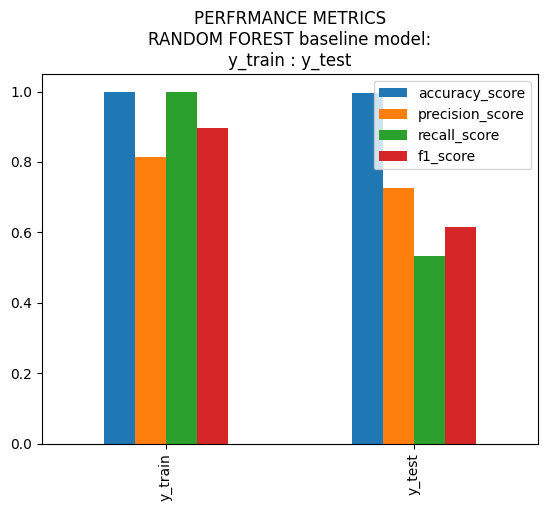

In [22]:
plt.figure(figsize = (10,5))
RF_metrics.plot(kind = 'bar', legend = True)
plt.title("PERFRMANCE METRICS\nRANDOM FOREST baseline model:\ny_train : y_test") 
plt.show()

# ROC metrics

### TEST data
#### Prediction Probabilities:

In [23]:
y_test_pred_proba_RF_baseline =  pipeline_Random_Forest.predict_proba(X_test)[:,1]
#y_test_pred_proba_RF_baseline

### ROC-AUC

In [24]:
logit_roc_auc        = roc_auc_score(y_test,    y_test_pred_proba_RF_baseline)
print(f'ROC-AUC_score[y_test]: {logit_roc_auc}')

ROC-AUC_score[y_test]: 0.8793845315904139


## ROC Curve

In [25]:
fpr, tpr, thresholds = roc_curve(y_test,    y_test_pred_proba_RF_baseline)

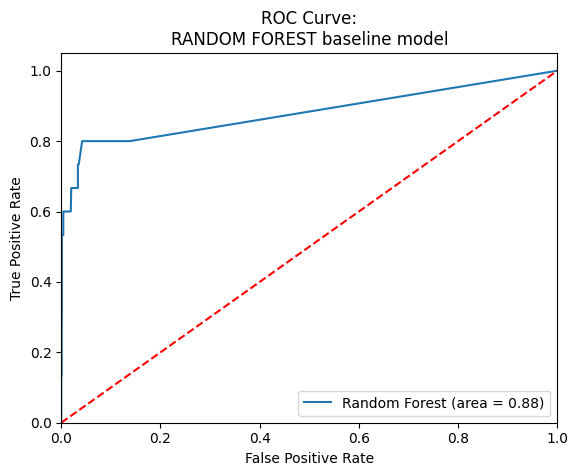

In [26]:
plt.figure()
plt.plot(fpr, tpr, label='Random Forest (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve:\nRANDOM FOREST baseline model')
plt.legend(loc="lower right")
plt.show()

### test set metrics is dropping
### There is some Overfitting occuring
### -->> which means we need to optimise the model.¶

#### RandomizedSearchCV

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

from sklearn.metrics import make_scorer, accuracy_score 
from sklearn.metrics._scorer import _SCORERS
#sorted(_SCORERS.keys())

In [28]:
# Take a look at which hyperparameters are on offer

rf = RandomForestClassifier(random_state = 42)
print('Random Forest Parameters options:')
rf_hyparams = list(rf.get_params())
rf_hyparams

Random Forest Parameters options:


['bootstrap',
 'ccp_alpha',
 'class_weight',
 'criterion',
 'max_depth',
 'max_features',
 'max_leaf_nodes',
 'max_samples',
 'min_impurity_decrease',
 'min_samples_leaf',
 'min_samples_split',
 'min_weight_fraction_leaf',
 'monotonic_cst',
 'n_estimators',
 'n_jobs',
 'oob_score',
 'random_state',
 'verbose',
 'warm_start']

In [29]:
model = pipeline_Random_Forest

# first set with wider ranges
param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [None, 8, 12, 16, 20, 30],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 5, 10],
    'classifier__max_leaf_nodes': [None, 50, 100, 200, 500],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}

## refined range
param_distributions_2 = {
    'classifier__n_estimators': [100, 200, 300,450, 500, 550, 600],
    'classifier__max_depth': [None, 8, 12, 16, 20, 3035, 40, 45],
    'classifier__min_samples_split': [8,9,10],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_leaf_nodes': [None,1, 10],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}
#my_metrics = [{'classifier__C': ['accuracy', 'precision', 'recall_macro', 'f1_macro']}]

#RF_gridsearch = GridSearchCV(estimator = model, param_grid = param_grid, cv = 4, scoring = 'precision', n_jobs=-1, verbose=2)#, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs',  return_train_score=False)  # use different metrics

# 3. Set up the RandomizedSearchCV
RF_random_search = RandomizedSearchCV(
    estimator= model,
    scoring = 'f1_macro',
    param_distributions=param_distributions_2,
    n_iter=20,       # Number of random combinations to try
    cv=5,            # 5-fold cross-validation
    random_state=42, # Ensures reproducibility
    n_jobs=-1        # Uses all available CPU cores
)


#pipeline_Random_Forest.get_params()
#RF_gridsearch.fit(X_train, y_train)

#RF_random_search.fit(X_train,y_train)

In [30]:
import time
start_time = time.time()

In [31]:
RF_random_search.fit(X_train,y_train)

print("Execution time:\n --- %s seconds ---" % (time.time() - start_time))

C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
35 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\pw

Execution time:
 --- 184.40070724487305 seconds ---


## RandomSearch Results:

In [32]:
print(RF_random_search.best_score_)
print(RF_random_search.best_params_)
print(RF_random_search.best_estimator_)

0.7487957948056255
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 8, 'classifier__min_samples_leaf': 1, 'classifier__max_leaf_nodes': None, 'classifier__max_features': 'log2', 'classifier__max_depth': None, 'classifier__class_weight': 'balanced'}
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['UPRN', '(H) Age - Fine', '(H) Presence of Elderly Parent',
       '(H) Number of Adults in Household', '(H) Length of Residency',
       '(H) Property Type 2011', '(H) Tenure 2011', '(H) Mosaic UK 7 Type',
       '(H) Affluence v2', '(H) Water Poverty Flag',
       '(H) Number of Children v3', '(H) Household Income v3 - Bands'],
      d...),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['ABP_Classification

In [33]:
best_RF_model = RF_random_search.best_estimator_
best_RF_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [34]:
RF_model_tuned = model.set_params(**RF_random_search.best_params_)
RF_model_tuned

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [35]:
import time
start_time = time.time()

RF_model_tuned.fit(X_train, y_train)

print("--- %s seconds ---" % (time.time() - start_time))

--- 8.298150300979614 seconds ---


In [36]:
# Model Performance
# we can get performance of the model on the TRAIN data set from 
RF_model_tuned_y_train_pred_RF =  RF_model_tuned.predict(X_train)
RF_model_tuned_y_train_pred_RF

array([0., 0., 0., ..., 0., 0., 0.])

In [37]:
## TEST data metrics
RF_model_tuned_y_test_pred_RF = RF_model_tuned.predict(X_test)
RF_model_tuned_y_test_pred_RF

array([0., 0., 0., ..., 0., 0., 0.])

In [38]:
d_tuned = {"accuracy_score_Tuned":  [metrics.accuracy_score(y_train, RF_model_tuned_y_train_pred_RF),  metrics.accuracy_score(y_test, RF_model_tuned_y_test_pred_RF)], 
     "precision_score_Tuned": [metrics.precision_score(y_train, RF_model_tuned_y_train_pred_RF), metrics.precision_score(y_test, RF_model_tuned_y_test_pred_RF)],
     "recall_score_Tuned":    [metrics.recall_score(y_train, RF_model_tuned_y_train_pred_RF), metrics.recall_score(y_test, RF_model_tuned_y_test_pred_RF)],
     "f1_score_Tuned":        [metrics.f1_score(y_train, RF_model_tuned_y_train_pred_RF), metrics.f1_score(y_test, RF_model_tuned_y_test_pred_RF)]    
    }
print("RANDOM FOREST RandomCV Tuned: With respect to target variable = 1\n")
RF_model_tuned_metrics = pd.DataFrame(data=d_tuned, index=['y_train', 'y_test'])
RF_model_tuned_metrics

RANDOM FOREST RandomCV Tuned: With respect to target variable = 1



,accuracy_score_Tuned,precision_score_Tuned,recall_score_Tuned,f1_score_Tuned
y_train,0.997767,0.734940,1.000000,0.847222
y_test,0.995128,0.615385,0.533333,0.571429


In [39]:
# Compare with baseline:
RF_metrics

,accuracy_score,precision_score,recall_score,f1_score
y_train,0.998579,0.813333,1.000000,0.897059
y_test,0.995940,0.727273,0.533333,0.615385


In [40]:

merged_metrics = pd.concat([RF_metrics.T, RF_model_tuned_metrics.T], ignore_index=False)
merged_metrics

,y_train,y_test
accuracy_score,0.998579,0.995940
precision_score,0.813333,0.727273
recall_score,1.000000,0.533333
f1_score,0.897059,0.615385
accuracy_score_Tuned,0.997767,0.995128
precision_score_Tuned,0.734940,0.615385
recall_score_Tuned,1.000000,0.533333
f1_score_Tuned,0.847222,0.571429


<Figure size 500x200 with 0 Axes>

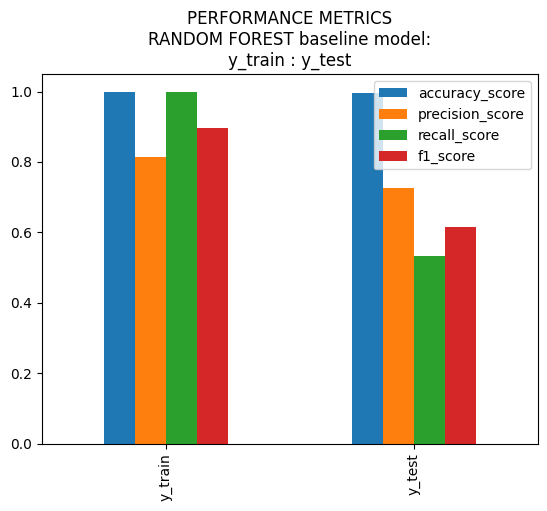

In [41]:
plt.figure(figsize = (5,2))
RF_metrics.plot(kind = 'bar', legend = True)
plt.title("PERFORMANCE METRICS\nRANDOM FOREST baseline model:\ny_train : y_test") 
plt.show()

<Figure size 500x200 with 0 Axes>

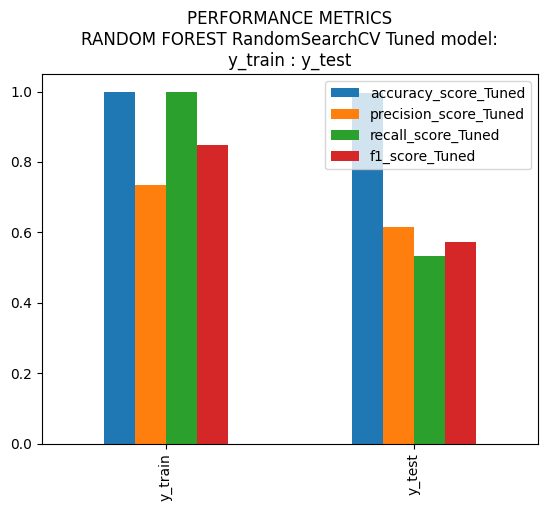

In [42]:
plt.figure(figsize = (5,2))
RF_model_tuned_metrics.plot(kind = 'bar', legend = True)
plt.title("PERFORMANCE METRICS\nRANDOM FOREST RandomSearchCV Tuned model:\ny_train : y_test") 
plt.show()

### For probability output:

In [43]:
import time
start_time = time.time()

RF_model_tuned.fit(X_train, y_train)

model_tuned_y_pred_RF = RF_model_tuned.predict(X_test)
print("--- %s seconds ---" % (time.time() - start_time))
model_tuned_y_pred_RF

--- 8.179953813552856 seconds ---


array([0., 0., 0., ..., 0., 0., 0.])

In [44]:
#model_tuned.fit(X_train, y_train)
model_tuned_y_pred_proba_RF_0 = RF_model_tuned.predict_proba(X_test)[:,0]
model_tuned_y_pred_proba_RF_1 = RF_model_tuned.predict_proba(X_test)[:,1]
model_tuned_y_pred_proba_RF_1.shape

(2463,)

In [45]:
RF_tuned_pred_proba_RF_0 = pd.DataFrame(model_tuned_y_pred_proba_RF_0)
RF_tuned_pred_proba_RF_1 = pd.DataFrame(model_tuned_y_pred_proba_RF_1)
RF_tuned_pred_proba_RF_0.head(3), RF_tuned_pred_proba_RF_1.head(3)


(         0
 0  0.99024
 1  1.00000
 2  1.00000,
          0
 0  0.00976
 1  0.00000
 2  0.00000)

In [46]:
RF_tuned_pred_class = pd.DataFrame(model_tuned_y_pred_RF)
RF_tuned_pred_class['binary_prediciton'] =  model_tuned_y_pred_RF
RF_tuned_pred_class = RF_tuned_pred_class[['binary_prediciton']]  
RF_tuned_pred_class#.head(4)

,binary_prediciton
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
2458,0.0
2459,0.0
2460,0.0
2461,0.0


In [47]:
RF_tuned_pred_proba_RF_0_1 = pd.merge(RF_tuned_pred_proba_RF_0, RF_tuned_pred_proba_RF_1, left_index=True, right_index=True)
RF_tuned_pred_prob = pd.merge(RF_tuned_pred_proba_RF_0_1, RF_tuned_pred_class, left_index=True, right_index=True)
RF_tuned_pred_prob.head(5)
RF_tuned_pred_prob.shape

(2463, 3)

In [48]:
RF_tuned_pred_prob.columns

Index(['0_x', '0_y', 'binary_prediciton'], dtype='str')

In [49]:
RF_tuned_pred_prob['binary_prediciton'].value_counts()

binary_prediciton
0.0    2450
1.0      13
Name: count, dtype: int64

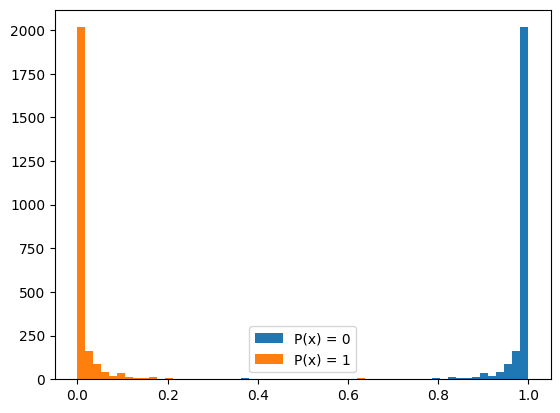

In [50]:
plt.hist(RF_tuned_pred_prob['0_x'], bins= 50, label = 'P(x) = 0')
plt.hist(RF_tuned_pred_prob['0_y'], bins= 50, label = 'P(x) = 1')
plt.legend()

In [51]:
df_NEW_predictions = pd.merge(df, RF_tuned_pred_prob, left_index=True, right_index=True, how = 'left')
df_NEW_predictions#.head(4)#.columns

,UPRN,ABP_Classification_Code,ABP_Classification_Desc,Communal Household Flag,(H) Age - Fine,(H) Household Composition,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,...,(H) Water Poverty Flag,(H) Fuel Poverty v2 Flag,(H) Number of Children v3,(H) Household Income v3 - Bands,Station_Ground_Code,LSOA11CD,INCIDENT,0_x,0_y,binary_prediciton
52,100120793465,RD04,Terraced,N,10,4.0,0,1,11.0,11,...,0,N,0,2,JX06,E01028512,0,1.000000,0.000000,0.0
84,100121291410,RD04,Terraced,N,4,5.0,0,1,7.0,3,...,0,N,1,5,JX06,E01028502,0,1.000000,0.000000,0.0
86,10011873896,RD04,Terraced,N,4,0.0,0,2,6.0,8,...,0,N,3,7,JX06,E01028502,0,0.996025,0.003975,0.0
138,100120801762,RD04,Terraced,N,4,3.0,0,2,6.0,6,...,0,N,2,6,JX06,E01028497,0,0.994395,0.005605,0.0
322,100120794646,RD04,Terraced,N,8,1.0,0,3,9.0,7,...,0,N,0,3,JX06,E01028488,0,0.373424,0.626576,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300155,10011889040,RD02,Detached,Y,4,4.0,0,1,4.0,3,...,0,N,0,4,JX06,E01028510,0,NaN,NaN,NaN
300156,10011889040,RD02,Detached,Y,4,4.0,0,1,4.0,3,...,0,N,0,4,JX06,E01028510,0,NaN,NaN,NaN
300160,100120949570,RD02,Detached,N,0,4.0,0,1,0.0,1,...,0,N,0,6,JX06,E01032954,0,NaN,NaN,NaN
300163,200004677301,RD03,Semi-Detached,N,0,5.0,0,1,0.0,1,...,0,N,0,7,JX06,E01028594,0,NaN,NaN,NaN


## AUC

In [52]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

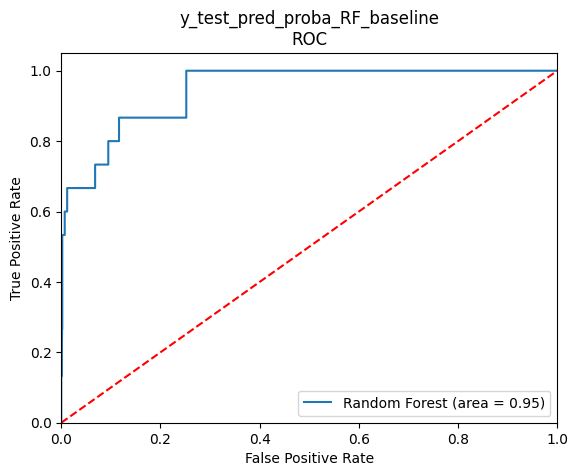

In [53]:
# ROC curve for the RandomForest baseline

#logit_roc_auc = roc_auc_score(y_train, y_train_pred_RF)
#fpr, tpr, thresholds = roc_curve(y_train, y_train_pred_RF)

y_test_pred_proba_RF_baseline =  pipeline_Random_Forest.predict_proba(X_test)[:,1]
# change for 
#model_y_pred_proba_RF_1 = RF_model_tuned.predict_proba(X_test)[:,1]
logit_roc_auc = roc_auc_score(y_test,    y_test_pred_proba_RF_baseline)
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba_RF_baseline)
y_test_pred_proba_RF_baseline
plt.figure()
plt.plot(fpr, tpr, label='Random Forest (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('y_test_pred_proba_RF_baseline\nROC')
plt.legend(loc="lower right")
plt.show()

# AUC: Random Forest Tuned

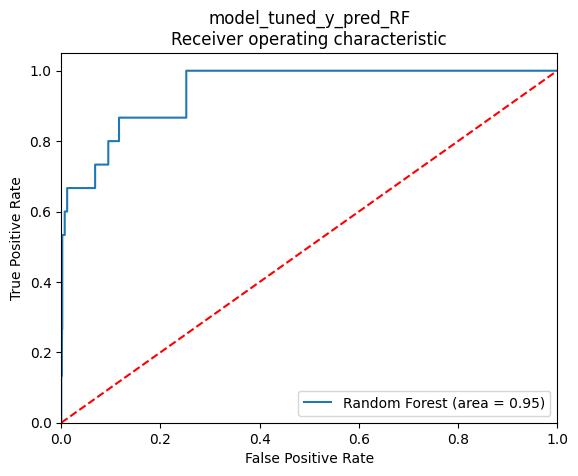

In [54]:
#y_test_pred_proba_RF_baseline =  pipeline_Random_Forest.predict_proba(X_test)[:,1]
# change for 
model_y_pred_proba_RF_1 = RF_model_tuned.predict_proba(X_test)[:,1]
logit_roc_auc = roc_auc_score(y_test,    model_y_pred_proba_RF_1)
fpr, tpr, thresholds = roc_curve(y_test, model_y_pred_proba_RF_1)
model_y_pred_proba_RF_1


# ROC curve for the RandomForest tuned
plt.figure()
plt.plot(fpr, tpr, label='Random Forest (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('model_tuned_y_pred_RF\nReceiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

In [59]:

print("RANDOM FOREST BASELINE MODEL:")
print(classification_report(y_test, y_test_pred_RF, target_names=target_names))

RANDOM FOREST BASELINE MODEL:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2448
           1       0.73      0.53      0.62        15

    accuracy                           1.00      2463
   macro avg       0.86      0.77      0.81      2463
weighted avg       1.00      1.00      1.00      2463



In [60]:
print("RANDOM FOREST TUNED MODEL:")
print(classification_report(y_test, model_tuned_y_pred_RF))

RANDOM FOREST TUNED MODEL:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2448
         1.0       0.62      0.53      0.57        15

    accuracy                           1.00      2463
   macro avg       0.81      0.77      0.78      2463
weighted avg       0.99      1.00      0.99      2463

